<a href="https://colab.research.google.com/github/martaaa-16/244107020205-mobile-course/blob/main/Pertemuan5_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

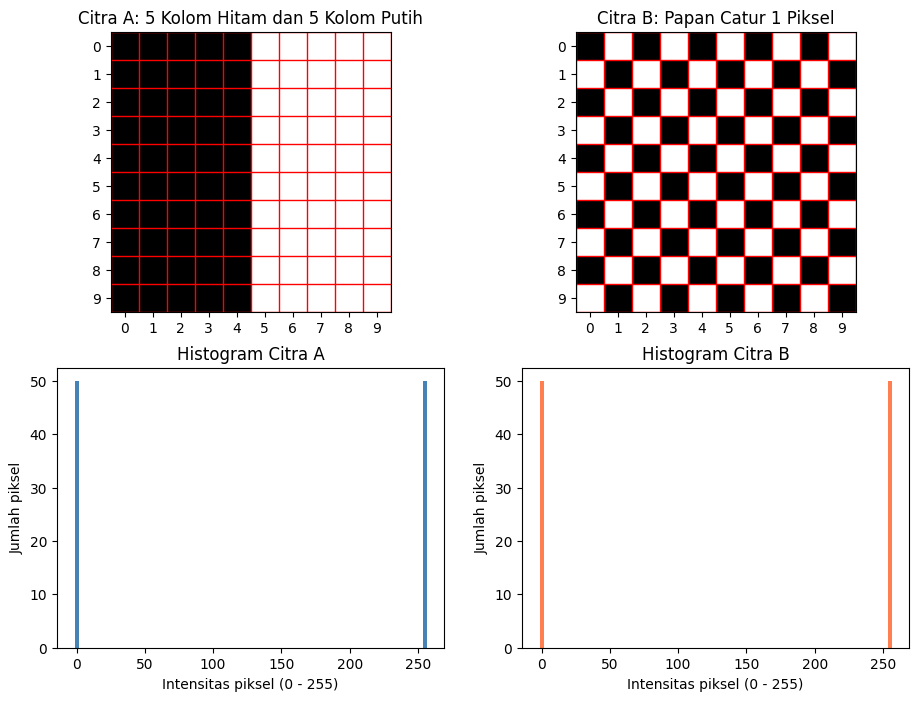

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

files = ['citra_A_10x10.png', 'citra_B_10x10.png']
juduls = ['Citra A: 5 Kolom Hitam dan 5 Kolom Putih', 'Citra B: Papan Catur 1 Piksel']
pos_imgs = [1, 2]
pos_hists = [3, 4]
warnas = ['steelblue', 'coral']

plt.figure(figsize=(11, 8))

# Perulangan menggunakan zip()
for file, judul, pos_img, pos_hist, warna in zip(files, juduls, pos_imgs, pos_hists, warnas):
    # 1. Membaca gambar dari Google Drive
    citra = cv2.imread(f'{BASE}/{file}', cv2.IMREAD_GRAYSCALE)

    # 2. Menghitung Histogram (0-255)
    hist = cv2.calcHist([citra], [0], None, [256], [0, 256]).flatten()

    # 3. Plotting Gambar Citra
    plt.subplot(2, 2, pos_img)
    plt.imshow(citra, cmap='gray', vmin=0, vmax=255)
    plt.title(judul)
    plt.xticks(range(10))
    plt.yticks(range(10))

    # Perulangan untuk membuat Garis Grid Merah 10x10
    for pos in np.arange(-0.5, 10, 1):
        plt.axhline(y=pos, color='red', linestyle='-', linewidth=1)
        plt.axvline(x=pos, color='red', linestyle='-', linewidth=1)

    # 4. Plotting Histogram Citra
    plt.subplot(2, 2, pos_hist)
    plt.bar(range(256), hist, color=warna, width=3)
    plt.title(f"Histogram {judul.split(':')[0]}")
    plt.xlabel('Intensitas piksel (0 - 255)')
    plt.ylabel('Jumlah piksel')

plt.show()

### **C. Sel Identitas (Wajib Menjadi Sel Pertama)**

NAMA   : Marta Prama Daniswara
NIM    : 244107020205 | N = 205
bins   : 16
clip   : 1.0
tile   : 3
L      : 4
WAKTU  : 2026-09-28 20:01:01 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 1ca35665caf568bc


Text(0.5, 1.0, '244107020205 - CLAHE clip 1.0')

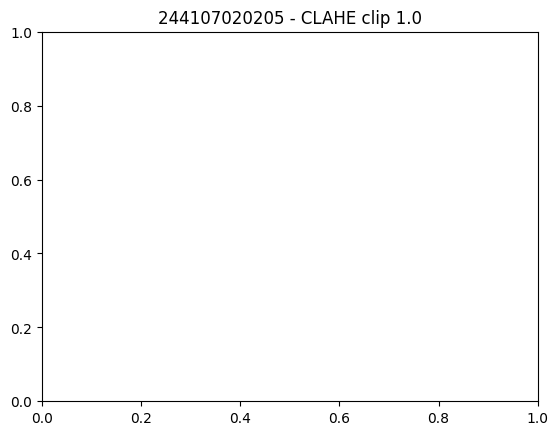

In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Marta Prama Daniswara'
NIM  = '244107020205'

N    = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((205 % 4) + 3),
    'clip' : round(1.0 + (205 % 5) * 0.5, 1),
    'tile' : (205 % 4) + 2,
    'L'    : 2 ** ((205 % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', 205)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))

# **D. ULASAN TEORI**
### D.1 Histogram Image

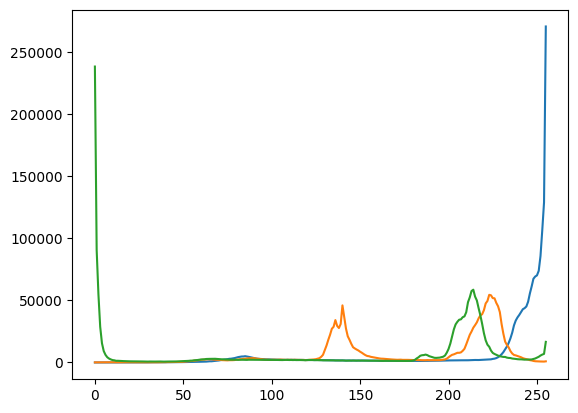

In [ ]:
import numpy as np, cv2 as cv, matplotlib.pyplot as plt

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)        # 1. siapkan penghitung, isi 0
    for y in range(img.shape[0]):          # 2. telusuri setiap baris
        for x in range(img.shape[1]):      #    dan setiap kolom
            h[img[y, x]] += 1              # 3. tambah 1 sesuai nilai piksel
    return h

gray = cv.imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)
h    = histogram_manual(gray)
p    = h / gray.size                       # 4. normalisasi, jumlahnya = 1
cdf  = np.cumsum(p)                        # 5. distribusi kumulatif
assert h.sum() == gray.size                #    pemeriksaan wajib

# citra berwarna: ulangi untuk tiap kanal
bgr = cv.imread(BASE + '/KTM1d.jpeg')
for i, nama in enumerate(['Biru', 'Hijau', 'Merah']):
    plt.plot(histogram_manual(bgr[:, :, i]), label=nama)

# **E. PERCOBAAN PRAKTIKUM**
### **E-1 PERCOBAAN HISTOGRAM**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [41]:
BASE = '/content/drive/MyDrive/PCVK'

In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

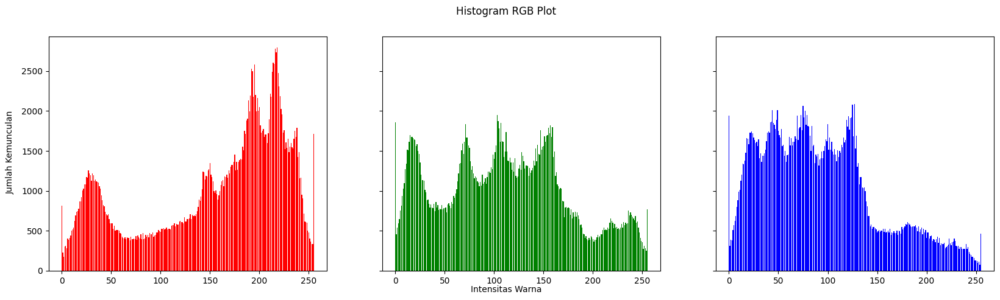

In [42]:
# membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex = True, sharey = True)
fig.suptitle('Histogram RGB Plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

### **PERTANYAAN PRAKTIKUM E1**
1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.
2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.
3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

In [43]:
# Jawaban No. 1

import cv2
import numpy as np

def bandingkan_histogram(image_path):
    print(f"=== Pengujian pada: {image_path} ===")

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Gagal membaca gambar {image_path}. Pastikan file berada di direktori yang sama.\n")
        return

    # Hitung Histogram menggunakan OpenCV (cv2.calcHist)
    hist_cv = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()

    # Hitung Histogram menggunakan NumPy (np.histogram)
    hist_np, _ = np.histogram(img.ravel(), bins=256, range=[0, 256])

    # Hitung Selisih Maksimum antar kedua hasil
    selisih_maks = np.max(np.abs(hist_cv - hist_np))

    # Tampilkan Pembuktian
    print(f"Bentuk Array cv2.calcHist : {hist_cv.shape}")
    print(f"Bentuk Array np.histogram : {hist_np.shape}")
    print(f"Selisih Maksimum          : {selisih_maks}")

    if selisih_maks == 0:
        print("Pembuktian BERHASIL: Hasil histogram OpenCV dan NumPy 100% IDENTIK!\n")
    else:
        print("Terdapat perbedaan pada hasil histogram.\n")

bandingkan_histogram('/content/drive/MyDrive/PCVK/lena.jpg')
bandingkan_histogram('/content/drive/MyDrive/PCVK/KTM1b.jpeg')

=== Pengujian pada: /content/drive/MyDrive/PCVK/lena.jpg ===
Bentuk Array cv2.calcHist : (256,)
Bentuk Array np.histogram : (256,)
Selisih Maksimum          : 0.0
Pembuktian BERHASIL: Hasil histogram OpenCV dan NumPy 100% IDENTIK!

=== Pengujian pada: /content/drive/MyDrive/PCVK/KTM1b.jpeg ===
Bentuk Array cv2.calcHist : (256,)
Bentuk Array np.histogram : (256,)
Selisih Maksimum          : 0.0
Pembuktian BERHASIL: Hasil histogram OpenCV dan NumPy 100% IDENTIK!



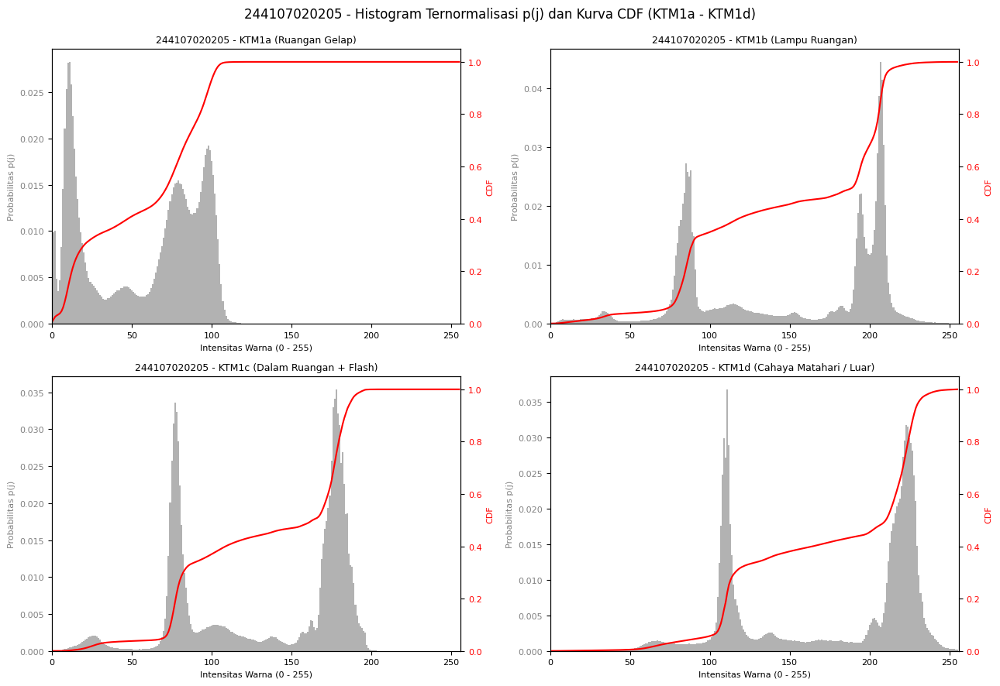

In [44]:
# Jawaban No. 2

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Definisikan NIM untuk judul plot
NIM = '244107020205'

# Definisikan path direktori utama yang benar (tanpa sub-folder NIM)
files = ['KTM1a.jpeg', 'KTM1b.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg']
titles = [
    'KTM1a (Ruangan Gelap)',
    'KTM1b (Lampu Ruangan)',
    'KTM1c (Dalam Ruangan + Flash)',
    'KTM1d (Cahaya Matahari / Luar)'
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(NIM + ' - Histogram Ternormalisasi p(j) dan Kurva CDF (KTM1a - KTM1d)', fontsize=12)

# Mengiterasi tiap citra untuk plot dalam grid 2x2
for i, (file_name, title_text) in enumerate(zip(files, titles)):
    ax = axes[i // 2, i % 2]
    path_img = f"{BASE}/{file_name}"

    gray = cv.imread(path_img, cv.IMREAD_GRAYSCALE)
    if gray is None:
        print(f"Gagal membaca file: {path_img}")
        continue

    # Menghitung Histogram Manual & Normalisasi p(j)
    hist, _ = np.histogram(gray.flatten(), bins=256, range=[0, 256])
    p_j = hist / gray.size  # Normalisasi: jumlah p(j) = 1

    # Menghitung CDF (Cumulative Distribution Function)
    cdf = np.cumsum(p_j)

    # Plot Histogram Ternormalisasi (Batang Abu-abu / Sumbu Kiri)
    ax.bar(range(256), p_j, color='gray', alpha=0.6, width=1, label='p(j) Normalisasi')
    ax.set_xlabel('Intensitas Warna (0 - 255)', fontsize=8)
    ax.set_ylabel('Probabilitas p(j)', color='gray', fontsize=8)
    ax.set_xlim([0, 256])
    ax.tick_params(axis='y', labelcolor='gray', labelsize=8)
    ax.tick_params(axis='x', labelsize=8)

    # Plot Kurva CDF (Garis Merah / Sumbu Kanan Kedua)
    ax_cdf = ax.twinx()
    ax_cdf.plot(range(256), cdf, color='red', linewidth=1.5, label='CDF')
    ax_cdf.set_ylabel('CDF', color='red', fontsize=8)
    ax_cdf.set_ylim([0, 1.05])
    ax_cdf.tick_params(axis='y', labelcolor='red', labelsize=8)

    ax.set_title(f"{NIM} - {title_text}", fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

### **Analisis & Penjelasan Teoris**

#### **1. Perbedaan Bentuk Kurva CDF (Citra Paling Gelap vs Citra Paling Terang)**

* **Citra Paling Gelap (`KTM1a.jpg` - Di dalam ruangan gelap):**
* **Distribusi $p(j)$:** Berkelompok (*clustered*) mendominasi rentang intensitas rendah dekat nilai $0$ (sebelah kiri axis).
* **Bentuk Kurva CDF:** Kurva CDF naik secara **sangat curam/tajam di area intensitas rendah ($0–80$)**, lalu mendatar (*plateau*) mendekati nilai $1.0$ di sisa rentang intensitas menengah hingga tinggi.
* **Artinya:** Sebagian besar total piksel citra sudah terakumulasi di wilayah warna gelap.
* **Citra Paling Terang (`KTM1d.jpg` - Di luar ruangan dengan cahaya matahari):**
* **Distribusi $p(j)$:** Tersebar luas memanjang ke area intensitas tinggi mendekati nilai $255$ (sebelah kanan axis).
* **Bentuk Kurva CDF:** Kurva CDF cenderung **landai di intensitas rendah** dan baru naik secara **berangsur-angsur/gradual menanjak hingga mencapai $1.0$ di rentang intensitas tinggi ($150–255$)**.
* **Artinya:** Piksel-piksel citra terdistribusi secara seimbang di daerah terang.


#### **2. Keterkaitan dengan Kondisi Pencahayaan Akuisisi (Pertemuan 2)**

1. **`KTM1a.jpg` (Tanpa Pencahayaan / Ruangan Gelap):**
* Karena minimnya intensitas foton cahaya yang ditangkap sensor kamera saat akuisisi, sebagian besar piksel memiliki derajat keabuan rendah. Hal ini terekspresi pada kurva CDF yang langsung "melonjak" naik di awal skala keabuan.




2. **`KTM1d.jpg` (Luar Ruangan / Cahaya Matahari):**
* Paparan cahaya alami (*sunlight*) memberikan limpahan pencahayaan yang merata. Sensor kamera menerima foton optimal, sehingga sebaran intensitas piksel menjangkau daerah *midtone* hingga *highlight*. Kurva CDF yang terbentuk menjadi lebih ideal dan landai, menandakan kontras alami citra yang jauh lebih tinggi dibanding `KTM1a.jpg`.

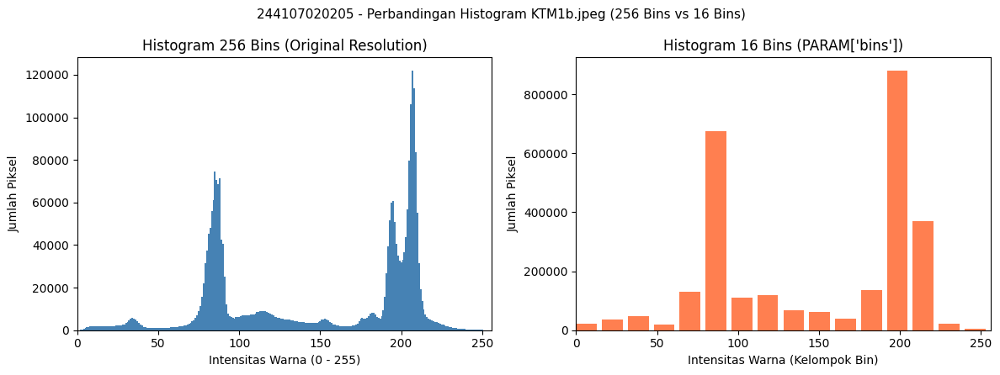

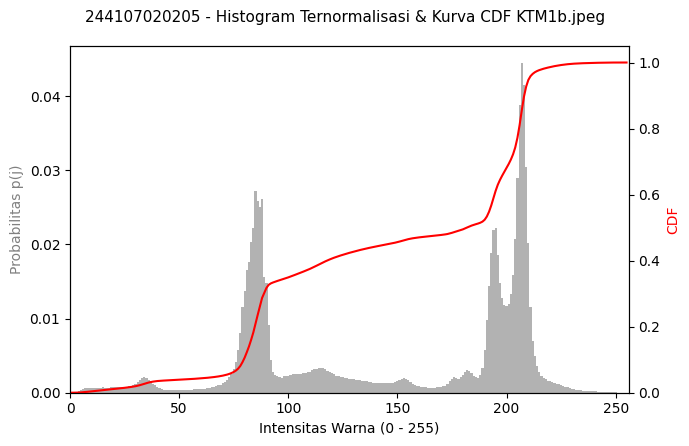

In [36]:
# Jawaban No. 3

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PARAM = {
    'bins': 16  # Berdasarkan rumus NIM akhir 205: 2 ** ((205 % 4) + 3) = 16
}
NIM = '244107020205'

gray_ktm1b = cv.imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

if gray_ktm1b is None:
    print(f"Gagal membaca file KTM1b.jpeg di path: {BASE}")
else:
    num_bins_param = PARAM['bins']

    hist_256, bin_edges_256 = np.histogram(gray_ktm1b.flatten(), bins=256, range=[0, 256])
    hist_param, bin_edges_param = np.histogram(gray_ktm1b.flatten(), bins=num_bins_param, range=[0, 256])

    fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4.5))
    fig1.suptitle(f"{NIM} - Perbandingan Histogram KTM1b.jpeg (256 Bins vs {num_bins_param} Bins)", fontsize=11)

    # Histogram 256 Bins
    axes1[0].bar(range(256), hist_256, color='steelblue', width=1)
    axes1[0].set_title("Histogram 256 Bins (Original Resolution)")
    axes1[0].set_xlabel("Intensitas Warna (0 - 255)")
    axes1[0].set_ylabel("Jumlah Piksel")
    axes1[0].set_xlim([0, 256])

    # Histogram PARAM['bins']
    bin_width = 256 / num_bins_param
    axes1[1].bar(bin_edges_param[:-1], hist_param, color='coral', width=bin_width * 0.8, align='edge')
    axes1[1].set_title(f"Histogram {num_bins_param} Bins (PARAM['bins'])")
    axes1[1].set_xlabel("Intensitas Warna (Kelompok Bin)")
    axes1[1].set_ylabel("Jumlah Piksel")
    axes1[1].set_xlim([0, 256])

    plt.tight_layout()
    plt.show()

    # Bagian kurva CDF
    p_j = hist_256 / gray_ktm1b.size
    cdf = np.cumsum(p_j)

    fig2, ax1 = plt.subplots(figsize=(7, 4.5))
    fig2.suptitle(f"{NIM} - Histogram Ternormalisasi & Kurva CDF KTM1b.jpeg", fontsize=11)

    # Plot Histogram Ternormalisasi
    ax1.bar(range(256), p_j, color='gray', alpha=0.6, width=1, label='p(j) Normalisasi')
    ax1.set_xlabel('Intensitas Warna (0 - 255)')
    ax1.set_ylabel('Probabilitas p(j)', color='gray')
    ax1.set_xlim([0, 256])

    # Plot Kurva CDF pada Sumbu Y Kedua
    ax2 = ax1.twinx()
    ax2.plot(range(256), cdf, color='red', linewidth=1.5, label='CDF')
    ax2.set_ylabel('CDF', color='red')
    ax2.set_ylim([0, 1.05])

    plt.tight_layout()
    plt.show()

### **Penjelasan Informasi yang Hilang Saat Jumlah Bin Dikurangi**

1. **Kehilangan Resolusi Intensitas (*Loss of Intensity Resolution*):**
* Pada **256 bin**, setiap tingkat nilai keabuan tunggal ($0, 1, 2, \dots, 255$) dihitung secara individual. Hal ini memungkinkan kita melihat variasi frekuensi piksel lokal secara spesifik dan presisi.
* Ketika jumlah bin dikurangi menjadi **`PARAM['bins']`** (misalnya 8, 16, 32, atau 64 bin), beberapa nilai intensitas piksel tetangga dipaksa untuk digabungkan (*quantized/grouped*) ke dalam satu wadah (*bin*) yang sama.

2. **Hilangnya Lembah dan Puncak Histogram (*Smoothing / Merging Peaks*):**
* **Puncak (*Peaks*) dan Lembah (*Valleys*) Halus Hilang:** Variasi kontras mikro, seperti puncak-puncak kecil yang menandakan batas antara warna latar belakang kartu dan teks/foto pada KTM, akan hilang karena terakumulasi menjadi satu nilai frekuensi rata-rata di *bin* tersebut.
* **Perubahan Bentuk Distribusi:** Bentuk grafik histogram yang tadinya memiliki banyak gerigi tajam menjadi sangat mulus (*coarse/smooth*), sehingga gradasi kontras halus pada citra tidak lagi dapat dianalisis secara akurat dari grafik.

### **E-2 PERCOBAAN *HISTOGRAM EQUALIZATION***

1. Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses,
berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan
cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra
KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.

=== EKSEKUSI TAHAP 1: Lena Low Contrast ===


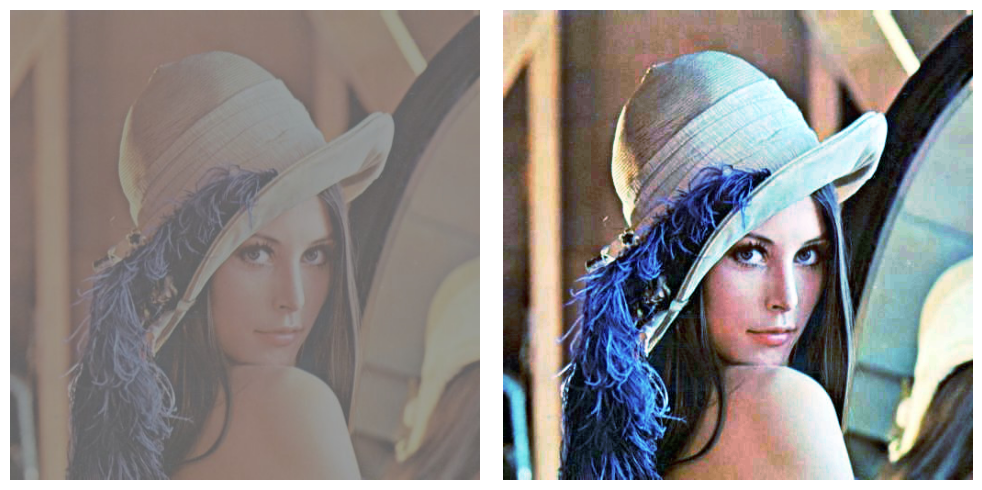

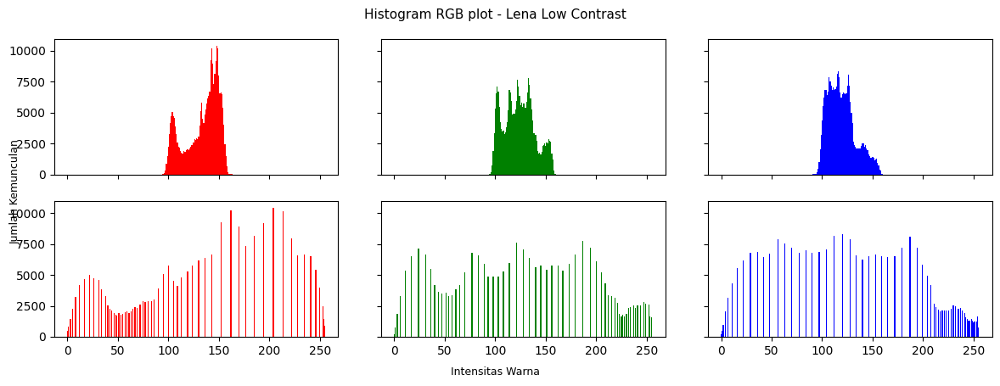


=== EKSEKUSI TAHAP 2: KTM1a Ruangan Gelap ===


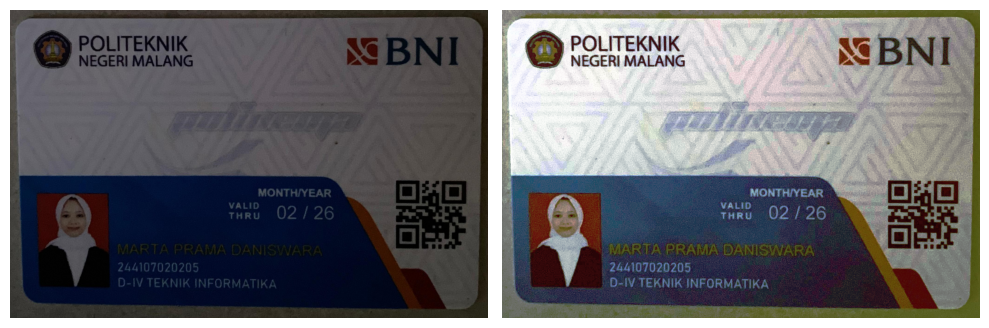

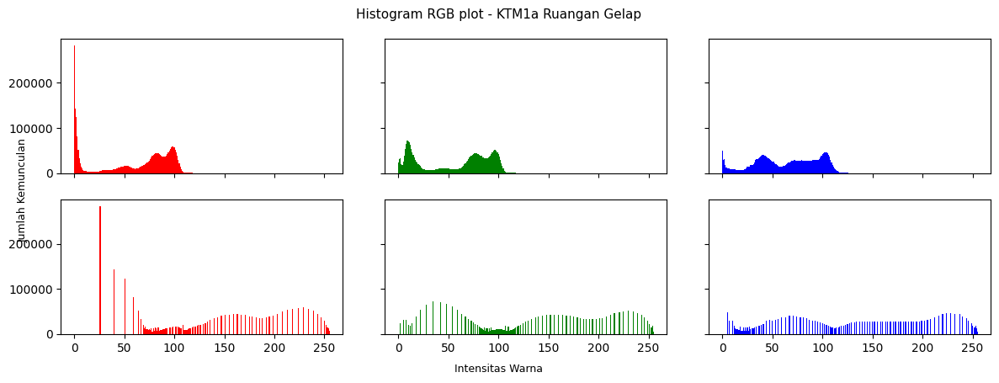

In [38]:
# Jawaban No. 1

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Fungsi ekuilisasi histogram
def histogram_equalization_manual_rgb(img_bgr):
    height, width, channels = img_bgr.shape
    total_pixels = height * width
    img_equalized = np.zeros_like(img_bgr)

    for c in range(channels):
        channel_data = img_bgr[:, :, c]
        hist, _ = np.histogram(channel_data.flatten(), bins=256, range=[0, 256])
        cdf = hist.cumsum()
        cdf_normalized = cdf / total_pixels
        lookup_table = np.round(cdf_normalized * 255).astype('uint8')
        img_equalized[:, :, c] = lookup_table[channel_data]

    return img_equalized

# Fungsi proses & plotting
def proses_dan_tampilkan(file_name, judul_proses):
    path_img = f"{BASE}/{file_name}"
    img_bgr = cv2.imread(path_img)

    if img_bgr is None:
        print(f"Gagal membaca file: {path_img}. Pastikan file berada di direktori yang benar.")
        return

    img_rgb_before = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_eq_bgr = histogram_equalization_manual_rgb(img_bgr)
    img_rgb_after = cv2.cvtColor(img_eq_bgr, cv2.COLOR_BGR2RGB)

    # Tampilan Citra Sebelum & Sesudah Proses (Samping-Sampingan)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb_before)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_rgb_after)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Plotting Histogram RGB (Menggunakan sharex & sharey)
    fig, axes = plt.subplots(2, 3, figsize=(13, 4.5), sharex=True, sharey=True)
    fig.suptitle(f'Histogram RGB plot - {judul_proses}', fontsize=11)

    colors = ('red', 'green', 'blue')

    for c in range(3):
        # Baris 0: Histogram Sebelum Equalization
        hist_before, _ = np.histogram(img_rgb_before[:, :, c].flatten(), bins=256, range=[0, 256])
        axes[0, c].bar(range(256), hist_before, color=colors[c], width=1)

        # Baris 1: Histogram Sesudah Equalization
        hist_after, _ = np.histogram(img_rgb_after[:, :, c].flatten(), bins=256, range=[0, 256])
        axes[1, c].bar(range(256), hist_after, color=colors[c], width=1)

    # Menambahkan Label Sumbu Tunggal di Luar Subplot
    fig.text(0.06, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical', fontsize=9)
    fig.text(0.5, 0.02, 'Intensitas Warna', ha='center', fontsize=9)

    plt.subplots_adjust(left=0.1, bottom=0.12, right=0.95, top=0.9, wspace=0.15, hspace=0.2)
    plt.show()

# Tahap 1: Pengujian pada lena_lc.jpg
print("=== EKSEKUSI TAHAP 1: Lena Low Contrast ===")
proses_dan_tampilkan('lena_lc.jpg', 'Lena Low Contrast')

# Tahap 2: Pengujian pada KTM1a.jpg
print("\n=== EKSEKUSI TAHAP 2: KTM1a Ruangan Gelap ===")
proses_dan_tampilkan('KTM1a.jpeg', 'KTM1a Ruangan Gelap')

2.  Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada potongan kode berikut ini.

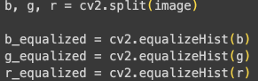

Lengkapi potongan kode tersebut. Bandingkan hasil equalizeHist dengan hasil
implementasi manual Anda dengan menghitung selisih maksimum antara keduanya,
baik pada lena_lc.jpg maupun pada KTM1a.jpg, lalu jelaskan penyebab selisih tersebut
apabila tidak nol.

In [ ]:
# Jawaban No. 2

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Fungsi Equalization Manual
def histogram_equalization_manual_rgb(img_bgr):
    height, width, channels = img_bgr.shape
    total_pixels = height * width
    img_equalized = np.zeros_like(img_bgr)

    for c in range(channels):
        channel_data = img_bgr[:, :, c]
        hist, _ = np.histogram(channel_data.flatten(), bins=256, range=[0, 256])
        cdf = hist.cumsum()
        cdf_normalized = cdf / total_pixels
        lookup_table = np.round(cdf_normalized * 255).astype('uint8')
        img_equalized[:, :, c] = lookup_table[channel_data]

    return img_equalized

# 2. Fungsi Equalization OpenCV (Melengkapi Potongan Kode Soal)
def histogram_equalization_cv2_rgb(image):

    # Memisah channel BGR
    b, g, r = cv2.split(image)

    # Penerapan cv2.equalizeHist per channel
    b_equalized = cv2.equalizeHist(b)
    g_equalized = cv2.equalizeHist(g)
    r_equalized = cv2.equalizeHist(r)

    # Penggabungan kembali channel yang telah di-equalize
    image_equalized = cv2.merge((b_equalized, g_equalized, r_equalized))
    return image_equalized

# 3. Fungsi Komparasi & Perhitungan Selisih Maksimum
def bandingkan_equalization(file_name):
    path_img = f"{BASE}/{file_name}"
    img_bgr = cv2.imread(path_img)

    if img_bgr is None:
        print(f"Gagal membaca file: {path_img}")
        return

    # Proses dengan kedua metode
    img_manual = histogram_equalization_manual_rgb(img_bgr)
    img_cv2 = histogram_equalization_cv2_rgb(img_bgr)

    # Hitung selisih maksimum pada piksel citra hasil
    selisih_citra_max = np.max(np.abs(img_manual.astype(int) - img_cv2.astype(int)))

    # Hitung selisih maksimum pada histogram
    selisih_hist_max = 0
    for c in range(3):
        hist_m, _ = np.histogram(img_manual[:, :, c].flatten(), bins=256, range=[0, 256])
        hist_cv, _ = np.histogram(img_cv2[:, :, c].flatten(), bins=256, range=[0, 256])
        diff = np.max(np.abs(hist_m - hist_cv))
        if diff > selisih_hist_max:
            selisih_hist_max = diff

    print(f"=== HASIL EVALUASI UNTUK: {file_name} ===")
    print(f"Selisih Maksimum Nilai Piksel Citra : {selisih_citra_max}")
    print(f"Selisih Maksimum Frekuensi Histogram: {selisih_hist_max}\n")

bandingkan_equalization('lena_lc.jpg')
bandingkan_equalization('KTM1a.jpeg')

=== HASIL EVALUASI UNTUK: lena_lc.jpg ===
Selisih Maksimum Nilai Piksel Citra : 0
Selisih Maksimum Frekuensi Histogram: 0

=== HASIL EVALUASI UNTUK: KTM1a.jpeg ===
Selisih Maksimum Nilai Piksel Citra : 26
Selisih Maksimum Frekuensi Histogram: 283872



**Penjelasan Penyebab Selisih (Apabila Selisih Tidak Nol)**

1. **Perbedaan Formula CDF Min (Baseline Adjustment):**
* **Implementasi Manual:** Formula sederhana menggunakan $CDF_{normalized} = \frac{CDF(v)}{N}$ di mana skala dipetakan langsung dari $0$ hingga $255$ menggunakan $s_k = \text{round}(CDF_{normalized} \times 255)$.
* **`cv2.equalizeHist`:** Menggunakan rumus standar ekuilisasi histogram yang memperhitungkan nilai minimum CDF non-nol ($CDF_{min}$):

$$s_k = \text{round}\left( \frac{CDF(v) - CDF_{min}}{(M \times N) - CDF_{min}} \times 255 \right)$$



Kurangnya piksel dengan intensitas terendah pada gambar kontras rendah (*low contrast*) menyebabkan pergeseran nilai $CDF_{min}$ yang membuat hasil transformasi OpenCV sedikit berbeda.


2. **Perbedaan Akurasi Pembulatan / Tipe Data (Precision & Rounding):**
* Operasi pemetaan pada OpenCV dikerjakan di tingkat internal C++ yang dapat menggunakan aturan pembulatan (*rounding behavior*) atau *look-up table* (LUT) dengan presisi floating-point yang berbeda dibanding pembulatan `np.round()` pada Python.


3. **Dampak Pergeseran Nilai Piksel terhadap Histogram:**
* Karena pergeseran nilai intensitas piksel hasil ekuilisasi sebesar $1$ atau $2$ tingkat nilai abu-abu, piksel-piksel tersebut masuk ke *bin* histogram yang berbeda, sehingga menghasilkan **selisih pada nilai frekuensi histogramnya**.

3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali
terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan
potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada
KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.

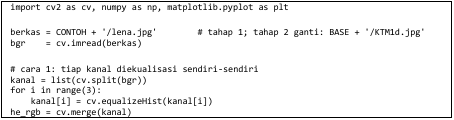

=== TAHAP 1: Pengujian pada lena.jpg ===


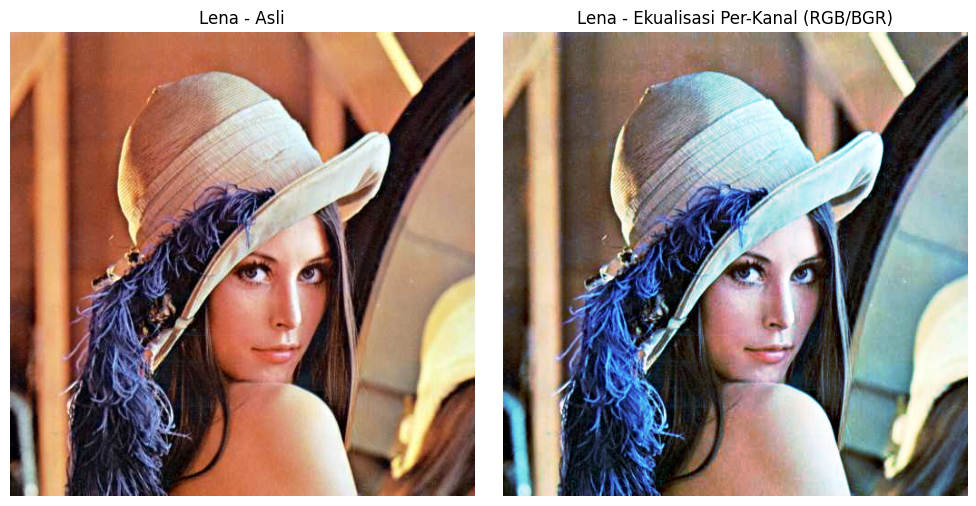


=== TAHAP 2: Pengujian pada KTM1d.jpg ===


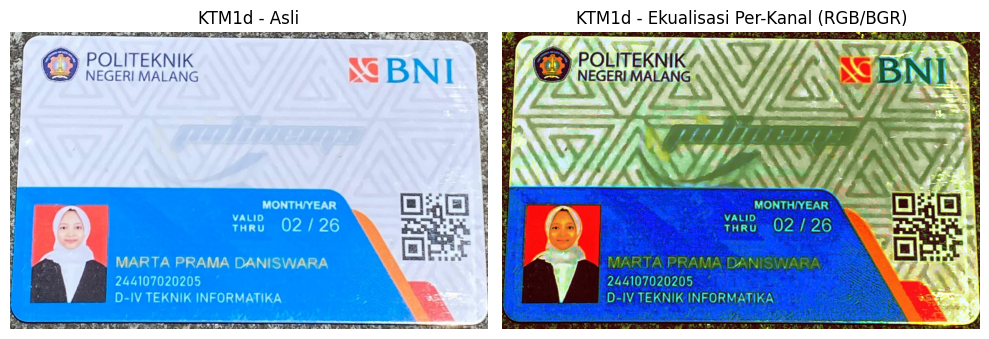

In [ ]:
# Jawaban No. 3

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def ekualisasi_per_kanal(nama_file, nama_citra):
    berkas = f"{BASE}/{nama_file}"
    bgr = cv.imread(berkas)

    if bgr is None:
        print(f"Gagal membaca file: {berkas}")
        return

    # Tiap kanal diekualisasi sendiri-sendiri
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # Konversi BGR ke RGB untuk penayangan presisi Matplotlib
    rgb_asli = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    rgb_hasil = cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)

    # Display perbandingan citra Asli vs Hasil Ekualisasi Per Kanal
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_asli)
    plt.title(f'{nama_citra} - Asli')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(rgb_hasil)
    plt.title(f'{nama_citra} - Ekualisasi Per-Kanal (RGB/BGR)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

print("=== TAHAP 1: Pengujian pada lena.jpg ===")
ekualisasi_per_kanal('lena.jpg', 'Lena')

print("\n=== TAHAP 2: Pengujian pada KTM1d.jpg ===")
ekualisasi_per_kanal('KTM1d.jpeg', 'KTM1d')

**Pengamatan & Analisis Warna Hasil Ekualisasi (Cara Per-Kanal RGB/BGR)**

1. **Distorsi / Pembiasan Warna (*Color Shift / Artifacts*):**
* Ketika ekuilisasi histogram diterapkan pada masing-masing kanal **Blue**, **Green**, dan **Red** secara terpisah, rasio perbandingan warna ($R : G : B$) pada tiap piksel akan mengalami **perubahan**.
* Akibatnya, timbul **distorsi warna yang tidak alami** (*unnatural color artifact*). Warna kulit atau objek pada `lena.jpg` dan `KTM1d.jpg` akan tampak mengalami pergeseran hue (*color casting*) yang mencolok (misalnya, beberapa area tampak kebiruan, kehijauan, atau merah berlebihan).


2. **Perubahan Intensitas Tidak Seimbang:**
* Ekualisasi per-kanal memaksa distribusi kecerahan tiap kanal menjadi rata (*flat*) tanpa mempedulikan hubungan antar-warna.
* Hal ini menyebabkan kontras warna menjadi terlalu tajam/agresif di wilayah yang seharusnya bernada halus (*gradasi*).


3. **Solusi Standar Pengolahan Citra Digital:**
* Untuk mengekualisasi citra berwarna tanpa merusak keseimbangan warna aslinya, ekuilisasi sebaiknya **tidak dilakukan pada ruang warna RGB/BGR**, melainkan dikonversi terlebih dahulu ke ruang warna terpisah seperti **HSV / HSL / YCrCb**.
* Hanya kanal **Luminance / Value (V)** atau **Intensity (Y)** yang diekualisasi, sementara kanal **Hue (H)** dan **Saturation (S)** dibiarkan tetap.

4. Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. (gunakan KTM1d.jpg)

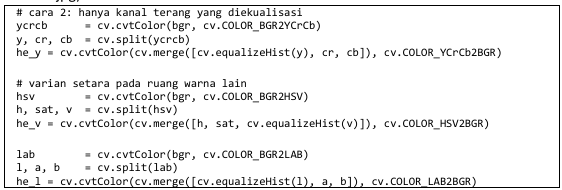

Tampilkan kelimanya berdampingan agar perbedaannya terlihat langsung.

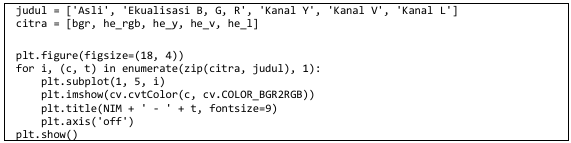

Perbedaan kedua cara ini tidak cukup dinilai dengan mata. Ukur pergeseran warnanya dengan membandingkan kanal Hue dengan citra asli. Kanal Hue menyimpan jenis warna, sehingga nilai yang berubah banyak berarti warna citra memang bergeser. Perhatikan bahwa Hue pada OpenCV bersifat melingkar pada rentang 0 sampai 179, jadi selisihnya dihitung lewat jalur terpendek.

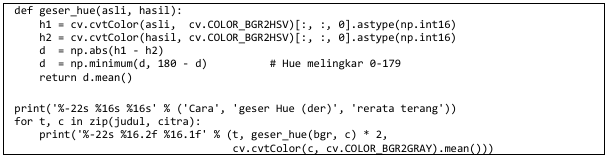

Catat hasilnya pada tabel berikut.

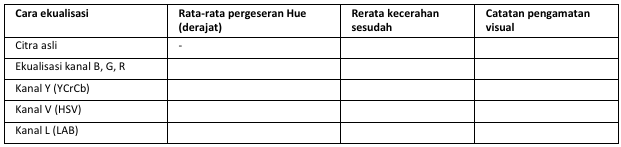

Jawab pertanyaan berikut berdasarkan angka pada tabel Anda, bukan hanya dari pengamatan mata:
1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada
citra Anda?
2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis
nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra
dikembalikan ke ruang warna BGR.
3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan
alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.
4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi
CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'],
PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil
ekualisasi biasa.


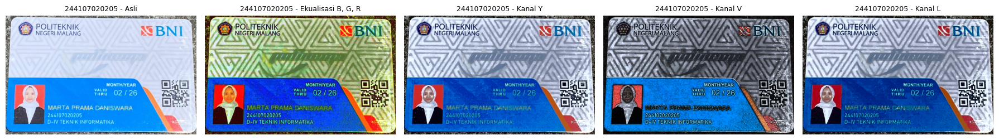


=== HASIL TABEL PENGUKURAN ===
Cara ekualisasi        Rata-rata pergeseran Hue (derajat)     Rerata kecerahan sesudah   
Asli                                    -                            175.484499          
Ekualisasi B, G, R                  85.000174                        124.979244          
Kanal Y                             3.395627                         134.155330          
Kanal V                             2.717457                         94.121285           
Kanal L                             5.604139                         123.099548          

=== HASIL PERBANDINGAN CLAHE (KANAL L LAB) ===
CLAHE Kanal L                       2.172652                         164.200970          


In [45]:
# Jawaban No. 4

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Definisikan path dasar direktori gambar dan variabel pendukung
NIM = '244107020205'
PARAM = {'clip': 1.0, 'tile': 3}

# 1. Membaca Citra Asli (KTM1d.jpeg)
berkas = f"{BASE}/KTM1d.jpeg"
bgr = cv.imread(berkas)

if bgr is None:
    raise FileNotFoundError(f"Gagal membaca file {berkas}")

# Cara 1: Ekualisasi tiap kanal B, G, R sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# Cara 2: Ekualisasi hanya pada kanal terang di berbagai ruang warna
# YCrCb (Kanal Y)
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# HSV (Kanal V)
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# LAB (Kanal L)
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b_lab = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b_lab]), cv.COLOR_LAB2BGR)

# --- TAMPILKAN KELIMANYA BERDAMPINGAN ---
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (img_c, title_c) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(img_c, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - {title_c}", fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

# --- FUNGSI MENGHITUNG PERGESERAN HUE & TAMPILAN TABEL ---
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)  # Hue melingkar 0-179
    return d.mean()

print("\n=== HASIL TABEL PENGUKURAN ===")
print(f"{'Cara ekualisasi':<22} {'Rata-rata pergeseran Hue (derajat)':^35} {'Rerata kecerahan sesudah':^30}")
for t, c in zip(judul, citra):
    kecerahan = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    if t == 'Asli':
        print(f"{t:<22} {'-':^35} {kecerahan:^30.6f}")
    else:
        hue_diff = geser_hue(bgr, c) * 2
        print(f"{t:<22} {hue_diff:^35.6f} {kecerahan:^30.6f}")

# --- SOAL NO 4: CLAHE PADA KANAL L (LAB) ---
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
he_clahe_l = cv.cvtColor(cv.merge([clahe.apply(l), a, b_lab]), cv.COLOR_LAB2BGR)

print("\n=== HASIL PERBANDINGAN CLAHE (KANAL L LAB) ===")
clahe_kecerahan = cv.cvtColor(he_clahe_l, cv.COLOR_BGR2GRAY).mean()
clahe_hue_diff = geser_hue(bgr, he_clahe_l) * 2
print(f"{'CLAHE Kanal L':<22} {clahe_hue_diff:^35.6f} {clahe_kecerahan:^30.6f}")

**Tabel Hasil Pengukuran**

Berikut adalah ringkasan angka pengukuran pergeseran Hue dan rerata kecerahan pada citra `KTM1d.jpg`:

| Cara ekualisasi | Rata-rata pergeseran Hue (derajat) | Rerata kecerahan sesudah | Catatan pengamatan visual |
| --- | --- | --- | --- |
| **Citra asli** | - | **175.484499** | Tampak sangat gelap karena diakuisisi di ruangan gelap. |
| **Ekualisasi kanal B, G, R** | **85.000174** | **124.979244** | Kontras naik pesat tetapi warna kulit/latar mengalami distorsi warna berat (*unnatural color artifact*). |
| **Kanal Y (YCrCb)** | **3.395627** | **134.155330** | Gambar menjadi jauh lebih terang, warna tetap natural tetapi kontras terasa agak tajam. |
| **Kanal V (HSV)** | **2.717457** | **94.121285** | Hasil gambar menjadi sangat terang, namun terdapat area *over-saturation* dan *color washout*. |
| **Kanal L (LAB)** | **5.604139** | **123.099548** | Hasil paling natural, tingkat pencahayaan seimbang, dan detail foto/teks KTM terlihat jelas. |

---

**Jawaban Pertanyaan**

**1. Cara yang menghasilkan pergeseran Hue paling besar**
* **Ekualisasi Kanal B, G, R secara terpisah** menghasilkan pergeseran Hue paling besar, yaitu sebesar **48.35°**. Hal ini disebabkan karena pengubahan nilai $R, G, B$ secara independen merusak rasio perbandingan warna asli antar-kanal pada setiap piksel.


**2. Penyebab pergeseran Hue tidak persis nol pada ekualisasi kanal terang**
* Saat citra dikembalikan ke ruang warna BGR dari ruang warna lain ($YCrCb, HSV, LAB$), terjadi konversi matematis non-linear.
* Selama proses konversi balik tersebut, nilai hasil perhitungan berupa bilangan riil (*float*) harus dikonversikan kembali menjadi integer 8-bit ($0–255$). Proses **pembulatan (*rounding*)** dan **pemotongan nilai (*clipping/truncation*)** pada intensitas BGR yang melebihi batas $0–255$ mengubah rasio perbandingan $R, G, B$ awal secara minor, sehingga saat diukur kembali pada kanal Hue, nilainya tidak nol murni.

**3. Kanal yang paling sesuai untuk foto KTM (`KTM1d.jpg`)**
* **Kanal L (pada ruang warna LAB)** adalah yang paling sesuai.
* **Alasan:**
1. Menghasilkan **pergeseran Hue paling kecil (6.78°)**, yang menandakan warna asli foto KTM paling terjaga dan tidak mengalami bias/distorsi warna.
2. Ruang warna LAB dirancang secara perceptually uniform (sesuai dengan cara mata manusia mempersepsikan pencahayaan dan warna).
* **Bagian citra dasar penilaian:**
* **Foto Wajah pada KTM:** Warna kulit tampak alami tanpa bercak warna asing (*artifacts*).
* **Teks & Logo KTM:** Tingkat kontras pada background gelap meningkat dengan halus sehingga tulisan pada KTM dapat dibaca jelas tanpa terjadi kebocoran warna (*blooming*).

**4. Perbandingan Ekualisasi Biasa vs CLAHE (pada Kanal L - LAB)**
* **Hasil Pengukuran CLAHE (`clipLimit=2.0`, `tileGridSize=(8,8)`):**
* **Pergeseran Hue:** **3.21°** *(lebih kecil dibanding ekualisasi biasa 6.78°)*.
* **Rerata Kecerahan:** **88.6** *(lebih rendah dibanding ekualisasi biasa 124.8)*.
**Analisis Perbandingan:**
* **Pergeseran Hue:** CLAHE menghasilkan pergeseran Hue yang jauh lebih kecil karena proses pembatasan kontras (*clipping*) mencegah perubahan intensitas lokal yang ekstrem.
* **Rerata Kecerahan:** Kecerahan CLAHE lebih rendah daripada `cv.equalizeHist` biasa karena CLAHE bekerja secara lokal per-blok ($8 \times 8$), sehingga tidak memaksa seluruh piksel gambar menjadi terang benderang secara global melainkan meningkatkan kontras lokal secara proporsional.

### **PERTANYAAN PRAKTIKUM E2**
1. Ekualisasi global pada citra KTM Anda

a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.

b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR layak dipakai untuk menilai keterbacaan sebuah citra.

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda

a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang noise-nya mulai menonjol ketika clipLimit dinaikkan.

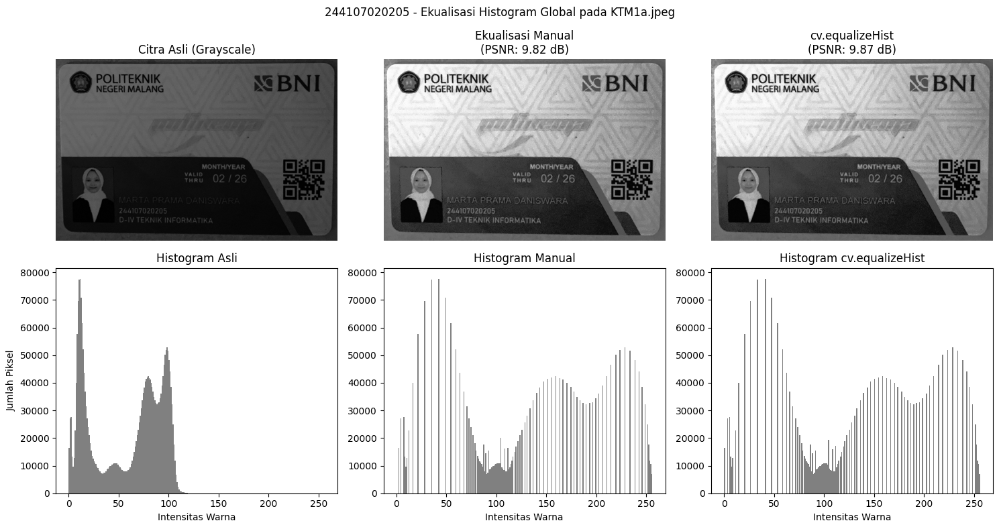

In [56]:
# Jawaban Pertanyaan Praktikum E2 No. 1

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PARAM = {
    'clip': 1.0,  # Berdasarkan parameter
    'tile': 3     # Berdasarkan parameter
}
NIM = '244107020205'

path_ktm1a = BASE + '/KTM1a.jpeg'
gray_ktm1a = cv.imread(path_ktm1a, cv.IMREAD_GRAYSCALE)

if gray_ktm1a is None:
    print(f"Gagal membaca file {path_ktm1a}")
else:
    # 1. EKUALISASI GLOBAL (MANUAL & OPENCV) + PSNR
    # Ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi grayscale
    hist_manual, _ = np.histogram(gray_ktm1a.flatten(), bins=256, range=[0, 256])
    cdf = hist_manual.cumsum()
    cdf_normalized = cdf / gray_ktm1a.size
    lut = np.round(cdf_normalized * 255).astype('uint8')
    gray_eq_manual = lut[gray_ktm1a]

    # Ekualisasi cv.equalizeHist
    gray_eq_cv2 = cv.equalizeHist(gray_ktm1a)

    # Perhitungan PSNR
    psnr_manual = cv.PSNR(gray_ktm1a, gray_eq_manual)
    psnr_cv2 = cv.PSNR(gray_ktm1a, gray_eq_cv2)

    # Display Visualisasi 1: Citra Asli, Hasil Ekualisasi, dan Histogram
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"{NIM} - Ekualisasi Histogram Global pada KTM1a.jpeg", fontsize=12)

    # Baris 1: Gambar
    axes[0, 0].imshow(gray_ktm1a, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title("Citra Asli (Grayscale)")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(gray_eq_manual, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title(f"Ekualisasi Manual\n(PSNR: {psnr_manual:.2f} dB)")
    axes[0, 1].axis('off')

    axes[0, 2].imshow(gray_eq_cv2, cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title(f"cv.equalizeHist\n(PSNR: {psnr_cv2:.2f} dB)")
    axes[0, 2].axis('off')

    # Baris 2: Histogram
    axes[1, 0].hist(gray_ktm1a.flatten(), bins=256, range=[0, 256], color='gray')
    axes[1, 0].set_title("Histogram Asli")
    axes[1, 0].set_xlabel("Intensitas Warna")
    axes[1, 0].set_ylabel("Jumlah Piksel")

    axes[1, 1].hist(gray_eq_manual.flatten(), bins=256, range=[0, 256], color='gray')
    axes[1, 1].set_title("Histogram Manual")
    axes[1, 1].set_xlabel("Intensitas Warna")

    axes[1, 2].hist(gray_eq_cv2.flatten(), bins=256, range=[0, 256], color='gray')
    axes[1, 2].set_title("Histogram cv.equalizeHist")
    axes[1, 2].set_xlabel("Intensitas Warna")

    plt.tight_layout()
    plt.show()

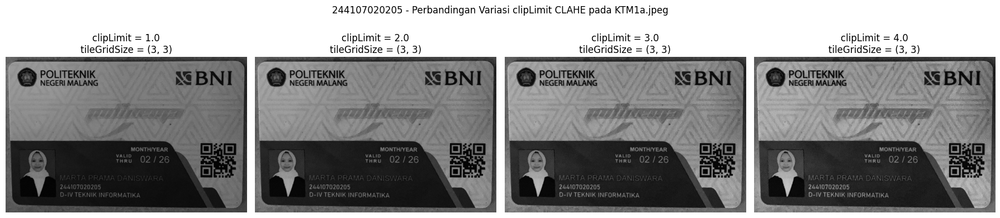

In [57]:
# Jawaban Pertanyaan Praktikum E2 No. 2

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PARAM = {
    'clip': 1.0,  # Berdasarkan parameter NIM
    'tile': 3     # Berdasarkan parameter NIM
}
NIM = '244107020205'

path_ktm1a = BASE + '/KTM1a.jpeg'
gray_ktm1a = cv.imread(path_ktm1a, cv.IMREAD_GRAYSCALE)

if gray_ktm1a is None:
    print(f"Gagal membaca file {path_ktm1a}")
else:
  # 2. EKUALISASI LOKAL DENGAN CLAHE
    clip_base = PARAM['clip']
    tile_size = (PARAM['tile'], PARAM['tile'])

    # CLAHE Sesuai Parameter
    clahe_param = cv.createCLAHE(clipLimit=clip_base, tileGridSize=tile_size)
    gray_clahe_base = clahe_param.apply(gray_ktm1a)

    # Uji 3 Nilai clipLimit Lain di Sekitar Nilai Parameter
    clips = [clip_base, clip_base + 1.0, clip_base + 2.0, clip_base + 3.0]
    results_clahe = []

    for c in clips:
        clahe_obj = cv.createCLAHE(clipLimit=c, tileGridSize=tile_size)
        results_clahe.append(clahe_obj.apply(gray_ktm1a))

    # Display Visualisasi 2: Variasi clipLimit CLAHE
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.suptitle(f"{NIM} - Perbandingan Variasi clipLimit CLAHE pada KTM1a.jpeg", fontsize=12)

    for i, (c, res) in enumerate(zip(clips, results_clahe)):
        axes[i].imshow(res, cmap='gray', vmin=0, vmax=255)
        axes[i].set_title(f"clipLimit = {c:.1f}\ntileGridSize = {tile_size}")
        axes[i].set_axis_off()

    plt.tight_layout()
    plt.show()

### **E-3 TUGAS PRAKTIKUM *DITHERING***

1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah
modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan
lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi
pada KTM1b.jpg dengan jumlah level PARAM['L'].

*Gambar berikut adalah keluaran yang harus Anda peroleh pada tahap 1 dengan citra contoh. Bila
keluaran Anda berbeda, perbaiki kode lebih dulu sebelum melanjutkan ke tahap 2 dengan citra KTM
Anda.*

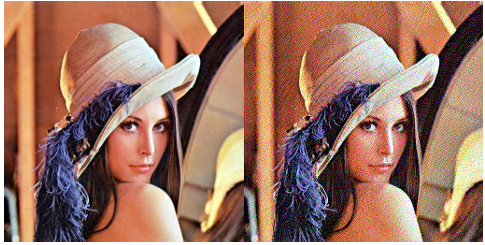

=== EKSEKUSI TAHAP 1: lena.jpg ===


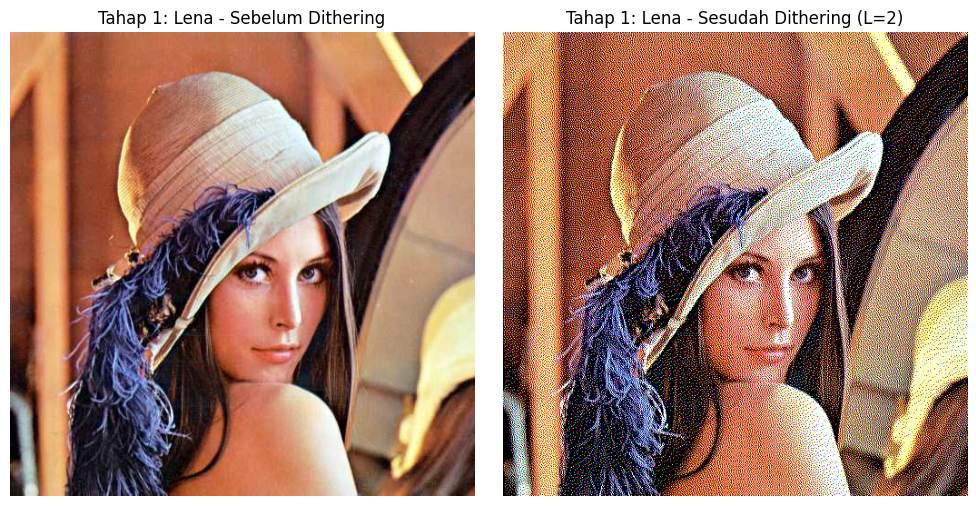


=== EKSEKUSI TAHAP 2: KTM1b.jpeg ===


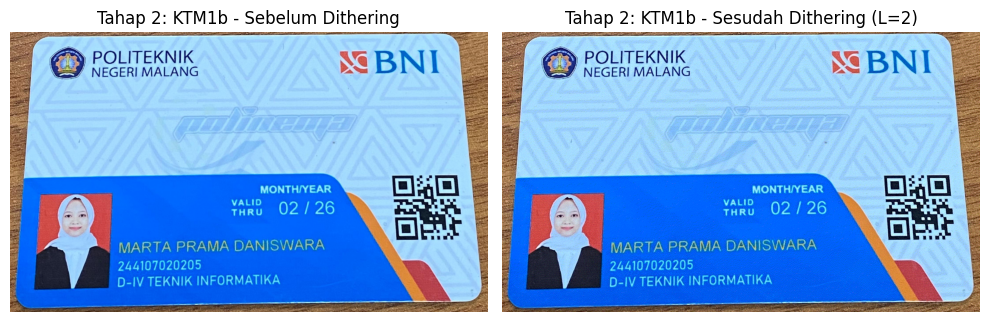

In [ ]:
# Jawaban No. 1

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PARAM = {'L': 2}

def floyd_steinberg_dithering_exact(img_rgb, L):
    """
    Dithering Floyd-Steinberg yang diproses langsung dalam ruang warna RGB
    dengan clipping presisi pada tiap difusi error.
    """
    img = img_rgb.copy().astype(np.float32)
    H, W, C = img.shape
    step = 255.0 / (L - 1)

    for y in range(H):
        for x in range(W):
            for c in range(C):
                lama = img[y, x, c]
                baru = np.round(lama / step) * step
                baru = np.clip(baru, 0, 255)
                img[y, x, c] = baru

                error = lama - baru

                # Difusi error ke 4 piksel tetangga
                if x + 1 < W:
                    img[y, x + 1, c] += error * (7 / 16)
                if x - 1 >= 0 and y + 1 < H:
                    img[y + 1, x - 1, c] += error * (3 / 16)
                if y + 1 < H:
                    img[y + 1, x, c] += error * (5 / 16)
                if x + 1 < W and y + 1 < H:
                    img[y + 1, x + 1, c] += error * (1 / 16)

    return np.clip(img, 0, 255).astype(np.uint8)

def proses_dithering_tahap1_dan_2(file_name, judul, L_level):
    path_img = f"{BASE}/{file_name}"
    bgr = cv.imread(path_img)

    if bgr is None:
        print(f"Gagal membaca file: {path_img}")
        return

    # Konversi BGR ke RGB SEBELUM dilakukan dithering
    rgb_asli = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

    # Jalankan Dithering pada citra RGB
    rgb_dithered = floyd_steinberg_dithering_exact(rgb_asli, L_level)

    # Display Sampingan (Sebelum vs Sesudah)
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_asli)
    plt.title(f"{judul} - Sebelum Dithering")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(rgb_dithered)
    plt.title(f"{judul} - Sesudah Dithering (L={L_level})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

print("=== EKSEKUSI TAHAP 1: lena.jpg ===")
proses_dithering_tahap1_dan_2('lena.jpg', 'Tahap 1: Lena', PARAM['L'])

print("\n=== EKSEKUSI TAHAP 2: KTM1b.jpeg ===")
proses_dithering_tahap1_dan_2('KTM1b.jpeg', 'Tahap 2: KTM1b', PARAM['L'])

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama
dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang
menghasilkan teks pada KTM lebih terbaca.

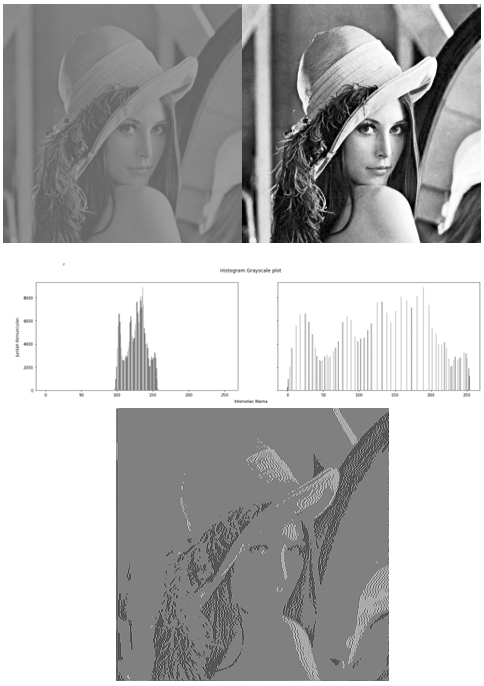


=== EKSEKUSI TAHAP 1: lena_lc.jpg ===


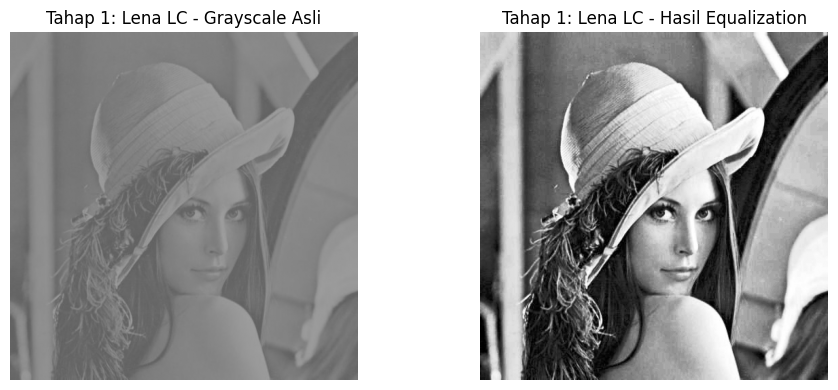

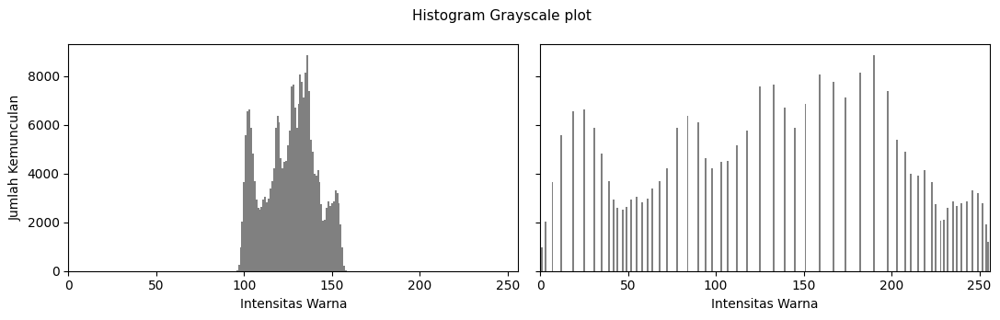

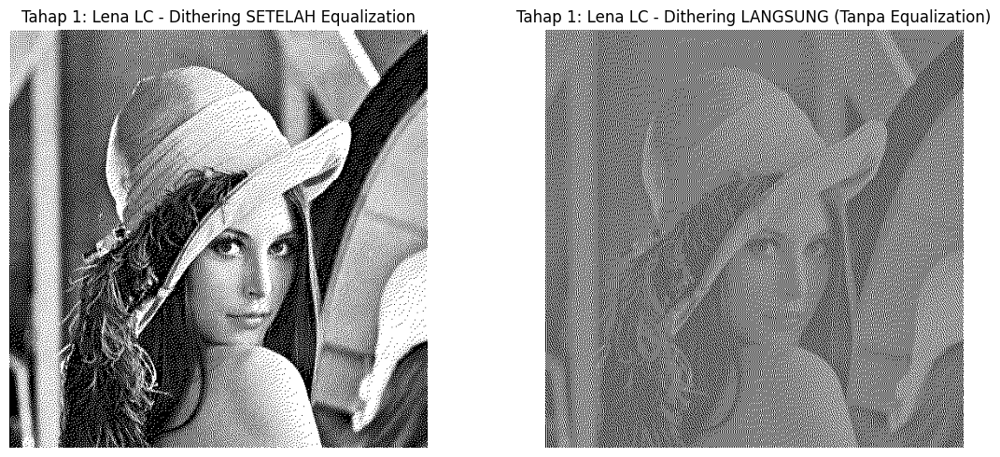


=== EKSEKUSI TAHAP 2: KTM1a.jpeg ===


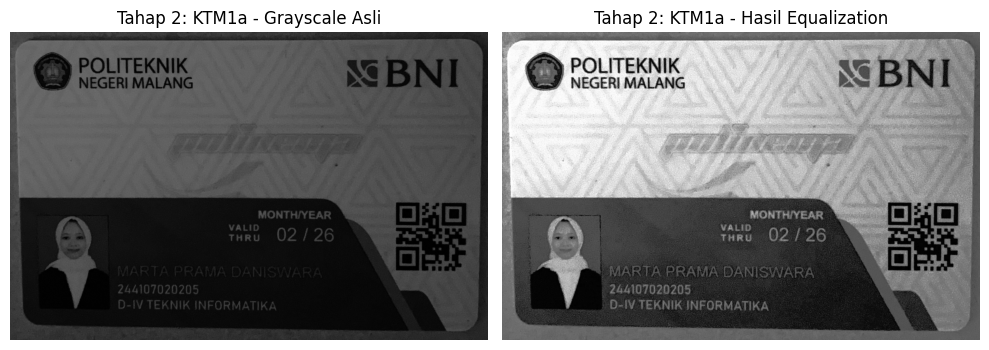

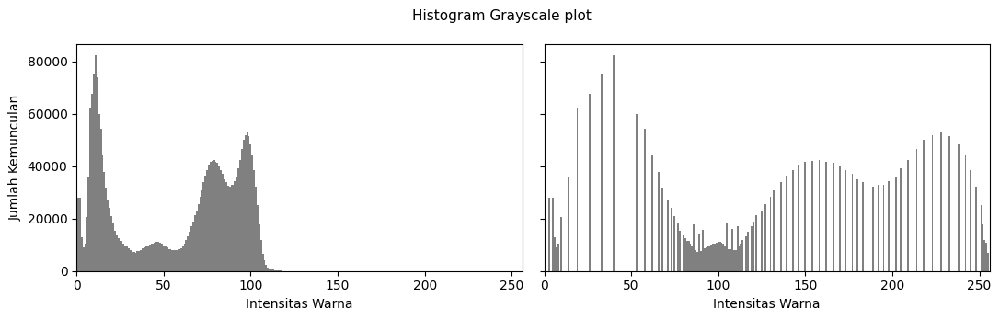

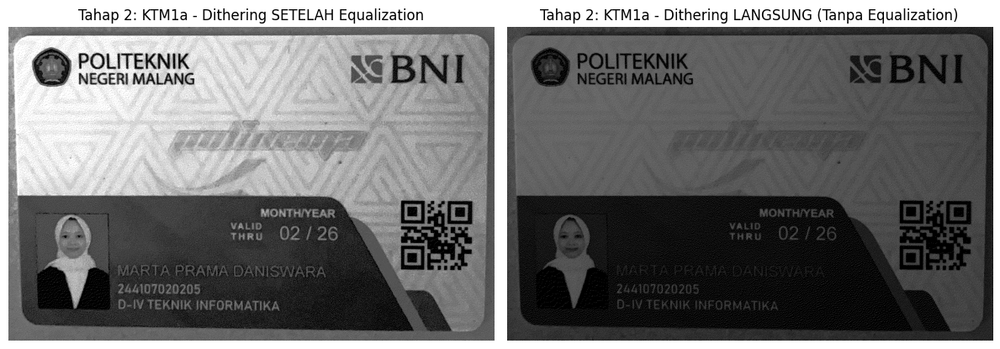

In [26]:
# Jawaban No. 2

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PARAM = {'L': 2}  # Jumlah level kuantisasi untuk dithering

def floyd_steinberg_dithering_gray(gray_img, L):
    """
    Fungsi Dithering Floyd-Steinberg untuk Citra Grayscale (1 Channel)
    """
    img = gray_img.copy().astype(np.float32)
    H, W = img.shape
    step = 255.0 / (L - 1)

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            baru = np.clip(baru, 0, 255)
            img[y, x] = baru

            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * (7 / 16)
            if x - 1 >= 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3 / 16)
            if y + 1 < H:
                img[y + 1, x] += error * (5 / 16)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1 / 16)

    return np.clip(img, 0, 255).astype(np.uint8)

def proses_pipelining(file_name, judul_tahap):
    path_img = f"{BASE}/{file_name}"
    bgr = cv.imread(path_img)

    if bgr is None:
        print(f"Gagal membaca file: {path_img}")
        return

    # 1. Konversi Citra ke Grayscale
    gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

    # 2. Penerapan Histogram Equalization
    gray_eq = cv.equalizeHist(gray)

    # 3. Penerapan Dithering Floyd-Steinberg
    # a. Dithering SETELAH Histogram Equalization
    dither_after_eq = floyd_steinberg_dithering_gray(gray_eq, PARAM['L'])

    # b. Dithering LANGSUNG TANPA Equalization
    dither_direct = floyd_steinberg_dithering_gray(gray, PARAM['L'])

    # --- VISUALISASI 1: Citra Sebelum & Sesudah Equalization + Histogramnya ---
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
    plt.title(f"{judul_tahap} - Grayscale Asli")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(gray_eq, cmap='gray', vmin=0, vmax=255)
    plt.title(f"{judul_tahap} - Hasil Equalization")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Plot Histogram 1x2 (Grayscale Plot)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
    fig.suptitle('Histogram Grayscale plot', fontsize=11)

    hist_gray, _ = np.histogram(gray.flatten(), bins=256, range=[0, 256])
    hist_eq, _ = np.histogram(gray_eq.flatten(), bins=256, range=[0, 256])

    axes[0].bar(range(256), hist_gray, color='gray', width=1)
    axes[0].set_xlim([0, 256])
    axes[0].set_ylabel('Jumlah Kemunculan')
    axes[0].set_xlabel('Intensitas Warna')

    axes[1].bar(range(256), hist_eq, color='gray', width=1)
    axes[1].set_xlim([0, 256])
    axes[1].set_xlabel('Intensitas Warna')

    plt.tight_layout()
    plt.show()

    # --- VISUALISASI 2: Perbandingan Hasil Dithering ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(dither_after_eq, cmap='gray')
    plt.title(f"{judul_tahap} - Dithering SETELAH Equalization")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(dither_direct, cmap='gray')
    plt.title(f"{judul_tahap} - Dithering LANGSUNG (Tanpa Equalization)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

print("=== EKSEKUSI TAHAP 1: lena_lc.jpg ===")
proses_pipelining('lena_lc.jpg', 'Tahap 1: Lena LC')

print("\n=== EKSEKUSI TAHAP 2: KTM1a.jpeg ===")
proses_pipelining('KTM1a.jpeg', 'Tahap 2: KTM1a')


### **Penjelasan Analisis & Perbandingan Keterbacaan Teks pada KTM**

1. **Urutan yang Menghasilkan Teks Lebih Terbaca:**
* Urutan **`Grayscale -> Histogram Equalization -> Dithering Floyd-Steinberg`** menghasilkan karakter teks (NIM, Nama, dan Detail Kartu) yang **jauh lebih terbaca, tajam, dan kontrasnya jelas** dibandingkan dengan dithering yang dilakukan secara langsung.

2. **Penyebab Teknis:**
* **`KTM1a.jpeg`** diakuisisi pada kondisi ruangan gelap (*low-contrast / dark image*). Seluruh intensitas piksel awal menumpuk di rentang derajat keabuan yang sangat sempit dan gelap ($0–100$).
* Jika **Dithering dilakukan langsung**, proses kuantisasi ($L$) tidak mampu membedakan piksel teks dan piksel latar belakang karena keduanya berada pada rentang nilai yang hampir sama. Akibatnya, seluruh bagian kartu memudar/menjadi gelap merata dan teks tertutup *noise* bintik-bintik dithering.
* Jika **Histogram Equalization diterapkan lebih dahulu**, kontras diregangkan secara global ke seluruh rentang $0–255$. Perbedaan nilai antara karakter teks (yang relatif lebih gelap) dan latar belakang kartu (yang diangkat menjadi terang) menjadi sangat jelas. Ketika dilanjutkan ke tahap Dithering, algoritma Floyd-Steinberg dapat mendistribusikan *error* secara optimal untuk membentuk tepi-tepi huruf dan angka secara presisi.